In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [3]:
df.shape

(1009, 14)

In [4]:
df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')

In [5]:
df = df.drop(columns=["ID", "No_Pation"])

In [6]:
df.columns = df.columns.str.lower()
df.head()

,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [7]:
df["gender"].unique()

<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str

In [8]:
df["gender"].unique()

<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str

In [9]:
df["gender"] = df["gender"].str.strip().str.upper()
df["gender"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [10]:
df["class"] = df["class"].str.strip()
df["class"].unique()

<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

In [11]:
df.isnull().sum()

gender    0
age       1
urea      1
cr        2
hba1c     3
chol      2
tg        2
hdl       1
ldl       2
vldl      1
bmi       0
class     0
dtype: int64

In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\admin\AppData\Local\Temp\ipykernel_21012\1086532638.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [14]:
df.isnull().sum()

gender    0
age       0
urea      0
cr        0
hba1c     0
chol      0
tg        0
hdl       0
ldl       0
vldl      0
bmi       0
class     0
dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


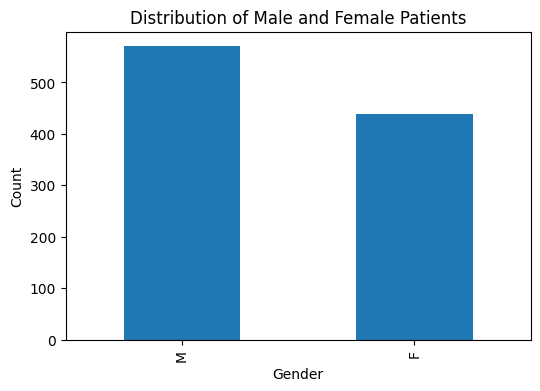

In [16]:
plt.figure(figsize=(6, 4))
df["gender"].value_counts().plot(kind="bar")
plt.title("Distribution of Male and Female Patients")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

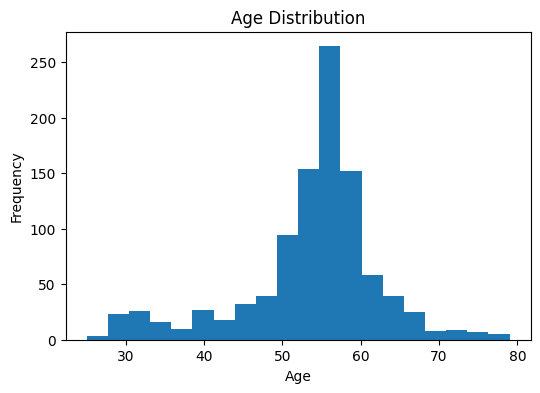

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

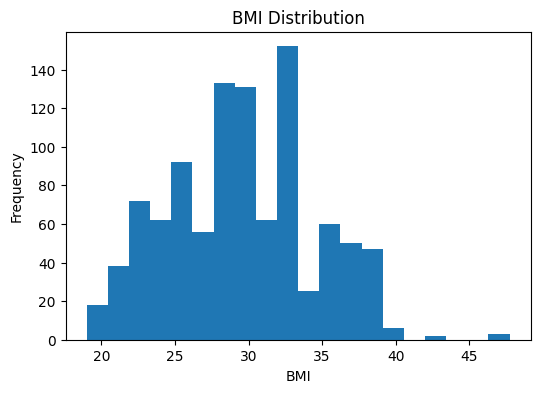

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

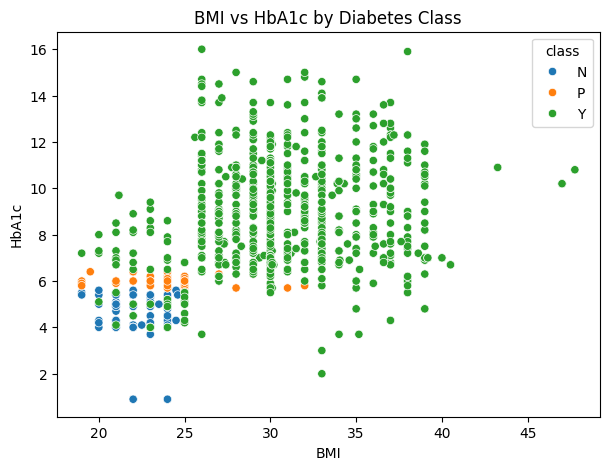

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="bmi", y="hba1c", hue="class")
plt.title("BMI vs HbA1c by Diabetes Class")
plt.xlabel("BMI")
plt.ylabel("HbA1c")
plt.show()

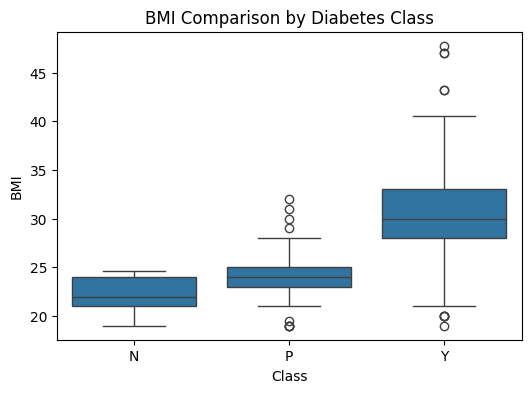

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="class", y="bmi")
plt.title("BMI Comparison by Diabetes Class")
plt.xlabel("Class")
plt.ylabel("BMI")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [22]:
X = df.drop(columns=["class"])
y = df["class"]

In [23]:
X = df.drop(columns=["class"])
y = df["class"]

In [24]:
X = pd.get_dummies(X, columns=["gender"], drop_first=False)
X.head()

,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,gender_F,gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,False,True
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,False,True


In [25]:
training_columns = X.columns.tolist()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [28]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

e:\uni shit\8th Sem\mlops\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.930693,0.924046,0.930693,0.925065
1,SVM,0.844884,0.713830,0.844884,0.773848
2,Decision Tree,0.983498,0.983541,0.983498,0.983245
3,Random Forest,0.983498,0.983651,0.983498,0.983034
4,KNN,0.877888,0.878911,0.877888,0.878188


In [29]:
results_df.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
2,Decision Tree,0.983498,0.983541,0.983498,0.983245
3,Random Forest,0.983498,0.983651,0.983498,0.983034
0,Logistic Regression,0.930693,0.924046,0.930693,0.925065
4,KNN,0.877888,0.878911,0.877888,0.878188
1,SVM,0.844884,0.713830,0.844884,0.773848


In [30]:
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model_name

'Decision Tree'

In [31]:
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model_name

'Decision Tree'

In [32]:
import os

os.path.exists("diabetes_model.pkl"), os.path.exists("training_columns.pkl")

(False, False)

In [33]:
import joblib

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(training_columns, "training_columns.pkl")

['training_columns.pkl']

In [34]:
import os

print(os.path.exists("diabetes_model.pkl"))
print(os.path.exists("training_columns.pkl"))

True
True
